# Training Data Analysis

Exploratory analysis of training founders, company coverage, and industries.

In [12]:
#@title Load Data
# cell_1

import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.common import load_config

In [13]:
# cell_2
from src.data import clean, load_targets, load_raw

cfg = load_config()
clean_training = clean(load_raw(cfg.data, dataset="training"))
clean_to_rank = clean(load_raw(cfg.data, dataset="ranking"))
targets = load_targets(cfg.data)
raw_training = load_raw(cfg.data, dataset="training")
raw_to_rank = load_raw(cfg.data, dataset="ranking")

In [14]:
clean_training.experience.head()

,person_id,order,company_id,title,job_type,start_date,end_date,is_c_suite,is_employee,is_executive,is_founder,is_on_board
0,SAZwRVReUVlXVFVR,1,NaN,Software Engineer,employee,2006-06-01,2006-09-01,False,True,False,False,False
1,SAZwRVReUVlXVFVR,2,SBVwFwAfBBgHAhcG,Software Engineer,employee,2007-02-01,2007-07-01,False,True,False,False,False
2,SAZwRVReUVlXVFVR,3,SBVwFQwKAQ0aHg==,Software Engineer,employee,2007-10-01,2009-06-01,False,True,False,False,False
3,SAZwRVReUVlXVFVR,4,SBVwHw0KCw8AAg==,Co-Founder & Chief Technology Officer,founder,2013-01-01,NaT,True,True,False,True,False
4,SAZwRVReUVlXVFVR,5,SBVwHw0KCw8AAg==,Co-founder & VP of Engineering,founder,2013-06-01,2018-09-01,False,True,False,True,False


In [15]:
clean_to_rank.experience.head()

,person_id,order,company_id,title,job_type,start_date,end_date,is_c_suite,is_employee,is_executive,is_founder,is_on_board
0,SAZwFQMZBAUwCQQQBTAa,1,NaN,Intern,employee,2010-02-01,2011-01-01,False,NaN,False,False,False
1,SAZwFQMZBAUwCQQQBTAa,2,NaN,"Product Design, Co-founder",founder,2011-04-01,2012-01-01,False,NaN,False,False,False
2,SAZwFQMZBAUwCQQQBTAa,3,SBVwBxc0BAYICAk=,Investor,investor,2012-01-01,2018-01-01,False,False,False,False,False
3,SAZwFQMZBAUwCQQQBTAa,4,SB9wBxc0BAYICAk=,Principal,employee,2012-10-01,NaT,False,True,False,False,False
4,SAZwFQMZBAUwCQQQBTAa,5,NaN,Independent,employee,2018-01-01,2021-01-01,False,True,False,False,False


In [16]:
unique_people = clean_training.experience["person_id"].dropna().unique()
founder_people = clean_training.experience[clean_training.experience["is_founder"] == True]["person_id"].dropna().unique()
print(f"Number of founders: {len(founder_people)}, Total Number of people: {len(unique_people)}")

unique_people = clean_to_rank.experience["person_id"].dropna().unique()
founder_people = clean_to_rank.experience[clean_to_rank.experience["is_founder"] == True]["person_id"].dropna().unique()
print(f"Number of founders: {len(founder_people)}, Total Number of people: {len(unique_people)}")

overlap_founders = set(founder_people).intersection(set(clean_training.experience["person_id"].dropna().unique()))

print(f"Overlap between training and to_rank: {len(overlap_founders)}")
print(overlap_founders)

Number of founders: 4772, Total Number of people: 4772
Number of founders: 120, Total Number of people: 120
Overlap between training and to_rank: 3
{'SAZwFRIDChwwCQQJHzoYGAoL', 'SAZwEBM0AQkZBAE4DD4GBgoXEQ4D', 'SAZwBAQfFwccMg0CBDgaGAoL'}


## Q1: How many people in the training experience data are actual founders?

A person is counted as a founder if they have at least one row in `founder_experience_training.csv` where `is_founder == True`.

In [17]:
# cell_3
unique_people = clean_training.experience["person_id"].dropna().unique()
founder_people = clean_training.experience[clean_training.experience["is_founder"] == True]["person_id"].dropna().unique()
print(f"Number of founders: {len(founder_people)}, Total Number of people: {len(unique_people)}")

unique_people = clean_to_rank.experience["person_id"].dropna().unique()
founder_people = clean_to_rank.experience[clean_to_rank.experience["is_founder"] == True]["person_id"].dropna().unique()
print(f"Number of founders: {len(founder_people)}, Total Number of people: {len(unique_people)}")

Number of founders: 4772, Total Number of people: 4772
Number of founders: 120, Total Number of people: 120


## Q2 & Q3: Founder companies in the target set and their industries

Here we look only at rows where `is_founder == True`, and:

1. Count how many *founder companies* appear in `target_variable_training.csv`.
2. Show the industry distribution for those companies (if any).

In [18]:
# cell_4

print("Below is training data analysis:\n")

training_founders_real = clean_training.experience[clean_training.experience["is_founder"] == True].dropna(subset=["person_id", "company_id"])
print(f'Number of real_founders: {len(set(training_founders_real['person_id']))}')

founder_company_ids = set(training_founders_real["company_id"].unique())
print(f'Number of companies they founded: {len(founder_company_ids)}')

target_company_ids = set(targets['company_id'].unique())
founders_with_target_companies = training_founders_real[training_founders_real['company_id'].isin(target_company_ids)]
num_founders_in_target_companies = len(founders_with_target_companies['person_id'].unique())
print(f'Number of founders with at least one company in target_variable_training: {num_founders_in_target_companies}')

# number of companies they have founded that are in target_variable training
target_company_ids = set(targets['company_id'].unique())
founder_companies_in_target = training_founders_real[
    training_founders_real['company_id'].isin(target_company_ids)
]
num_companies_founded_in_target = len(founder_companies_in_target['company_id'].unique())
print(f'Number of companies founded that are in target_variable training: {num_companies_founded_in_target}')

# number of companies with null `multiple` in targets table
null_multiple_count = targets['multiple'].isna().sum()
print(f'Number of companies with null multiple in targets table: {null_multiple_count}')

# number of companies they have founded that are NOT in target_variable training
non_target_company_ids = set(training_founders_real['company_id'].unique()) - target_company_ids
num_companies_founded_not_in_target = len(non_target_company_ids)
print(f'Number of companies founded that are NOT in target_variable training: {num_companies_founded_not_in_target}')

# how many of these non-target companies appear in company_info
company_info_ids = set(clean_training.company_info['company_id'].unique())
non_target_in_company_info = non_target_company_ids & company_info_ids
print(f'Number of these not-covered companies that are in company_info: {len(non_target_in_company_info)}')

# how many of these have actual performance data (non-null in a chosen performance column)
performance_col = 'performance'
non_target_with_performance = clean_training.company_info[
    (clean_training.company_info['company_id'].isin(non_target_in_company_info)) &
    (clean_training.company_info[performance_col].notna())
]
pct_with_performance = len(non_target_with_performance) / len(non_target_in_company_info) * 100
print(f'Percentage of these not-covered companies that have actual performance: {pct_with_performance:.1f}%')

# companies that have either multiple founders or performance data
companies_with_multiple_or_performance = target_company_ids.union(non_target_with_performance['company_id'])

pct_with_multiple_or_performance = len(companies_with_multiple_or_performance) / 4937 * 100
print(f'Number of companies with either multiple founders or performance data: {len(companies_with_multiple_or_performance)}')
print(f'Percentage of all founded companies that have either multiple founders or performance data: {pct_with_multiple_or_performance:.1f}%')


# Number of real founders have at least one company in target_variable_training and that same company is in clean_training.company_info
company_info_ids = set(clean_training.company_info['company_id'].unique())
founders_in_target_and_company_info = training_founders_real[
    training_founders_real['company_id'].isin(target_company_ids) &
    training_founders_real['company_id'].isin(company_info_ids)
]
num_founders_in_target_and_company_info = len(founders_in_target_and_company_info['person_id'].unique())
print(f'Number of real founders with at least one company in target_variable_training and company_info: {num_founders_in_target_and_company_info}')

founder_in_inference = ['SAZwFRIDChwwCQQJHzoYGAoL', 'SAZwEBM0AQkZBAE4DD4GBgoXEQ4D', 'SAZwBAQfFwccMg0CBDgaGAoL']

# number of founders in training after moveing the founder_in_infernce from training data
all_training_founders = set(training_founders_real['person_id'].unique())
founders_after_removal = all_training_founders - set(founder_in_inference)
print(f'Number of founders in training after removing inference founders: {len(founders_after_removal)}')
inference_founder_ids = set(clean_to_rank.experience[clean_to_rank.experience['is_founder'] == True]['person_id'].dropna().unique())
overlapping_founders = all_training_founders & inference_founder_ids
founders_after_removing_overlap = all_training_founders - overlapping_founders
print(f'Number of founders in training after removing overlapping founders: {len(founders_after_removing_overlap)}')
missing_founded_company_ids = set(targets[targets['company_founded'].isna()]['company_id'].unique())
founders_to_remove_due_to_missing_founded = training_founders_real[training_founders_real['company_id'].isin(missing_founded_company_ids)]['person_id'].unique()
founders_after_removing_missing_founded = all_training_founders - set(founders_to_remove_due_to_missing_founded)
print(f'Number of founders in training after removing founders with missing founded year: {len(founders_after_removing_missing_founded)}')
print(f'Company IDs with missing founded year in targets: {missing_founded_company_ids}')

Below is training data analysis:

Number of real_founders: 4772
Number of companies they founded: 4937
Number of founders with at least one company in target_variable_training: 4772
Number of companies founded that are in target_variable training: 2000
Number of companies with null multiple in targets table: 0
Number of companies founded that are NOT in target_variable training: 2937
Number of these not-covered companies that are in company_info: 2644
Percentage of these not-covered companies that have actual performance: 53.2%
Number of companies with either multiple founders or performance data: 3406
Percentage of all founded companies that have either multiple founders or performance data: 69.0%
Number of real founders with at least one company in target_variable_training and company_info: 4772
Number of founders in training after removing inference founders: 4769
Number of founders in training after removing overlapping founders: 4769
Number of founders in training after removing f

In [19]:
print("Below is inference data analysis: \n")

inference_data = clean_to_rank

inference_founders_real = inference_data.experience[inference_data.experience["is_founder"] == True].dropna(subset=["person_id", "company_id"])
print(f'Number of real_founders: {len(set(inference_founders_real['person_id']))}')

founder_company_ids = set(inference_founders_real["company_id"].unique())
print(f'Number of companies they founded: {len(founder_company_ids)}')

target_company_ids = set(targets['company_id'].unique())
founders_with_target_companies = inference_founders_real[inference_founders_real['company_id'].isin(target_company_ids)]
num_founders_in_target_companies = len(founders_with_target_companies['person_id'].unique())
print(f'Number of founders with at least one company in target_variable_training: {num_founders_in_target_companies}')

# Number of real founders have at least one company in target_variable_training and that same company is in clean_training.company_info
company_info_ids = set(clean_training.company_info['company_id'].unique())
founders_in_target_and_company_info = inference_founders_real[
    inference_founders_real['company_id'].isin(target_company_ids) &
    inference_founders_real['company_id'].isin(company_info_ids)
]
num_founders_in_target_and_company_info = len(founders_in_target_and_company_info['person_id'].unique())
print(f'Number of real founders with at least one company in target_variable_training and company_info: {num_founders_in_target_and_company_info}')
print(founders_in_target_and_company_info['person_id'].unique())

# Companie ids in targets_variable that these founders are associated with
founder_in_inference = ['SAZwFRIDChwwCQQJHzoYGAoL', 'SAZwEBM0AQkZBAE4DD4GBgoXEQ4D', 'SAZwBAQfFwccMg0CBDgaGAoL']
founder_in_inference_company_ids = set(inference_founders_real[inference_founders_real['person_id'].isin(founder_in_inference)]['company_id'].unique())
print(f'Number of companies in targets_variable that these founders are associated with: {founder_in_inference_company_ids}')


Below is inference data analysis: 

Number of real_founders: 120
Number of companies they founded: 163
Number of founders with at least one company in target_variable_training: 3
Number of real founders with at least one company in target_variable_training and company_info: 3
['SAZwFRIDChwwCQQJHzoYGAoL' 'SAZwEBM0AQkZBAE4DD4GBgoXEQ4D'
 'SAZwBAQfFwccMg0CBDgaGAoL']
Number of companies in targets_variable that these founders are associated with: {'SBVwBAgFCgMGGQ==', 'SBVwRVETOgECAAAVBTYCBA=='}


In [20]:
exp = clean_training.experience.copy()
exp["start_date"] = pd.to_datetime(exp["start_date"], errors="coerce")
exp["end_date"] = pd.to_datetime(exp["end_date"], errors="coerce")

latest_jobs = exp.sort_values("start_date").groupby("person_id").tail(1)
current_mask = latest_jobs["end_date"].isna()
current_founders = (current_mask & latest_jobs["is_founder"].astype(bool)).sum()
current_board = (current_mask & latest_jobs["is_on_board"].astype(bool)).sum()
current_exec = (current_mask & latest_jobs["is_executive"].astype(bool)).sum()
current_c_suite = (current_mask & latest_jobs["is_c_suite"].astype(bool)).sum()
current_employee = (current_mask & latest_jobs["is_employee"].astype(bool)).sum()
current_total = int(current_mask.sum())
current_total, current_founders, current_board, current_exec, current_c_suite, current_employee

(4120,
 np.int64(1719),
 np.int64(1550),
 np.int64(575),
 np.int64(1253),
 np.int64(3779))

## Q5: Past experience titles and potential feature use

Here we inspect the distribution of past job titles, and build a simple text field that concatenates all titles per person. This can be used either as:

- Input to an LLM for categorization (Q5.1).
- Input to a text featurizer (e.g. bag-of-words) for a ranking model like XGBoost (Q5.2).

In [21]:
title_counts = (
    clean_training.experience["title"]
    .astype(str)
    .str.strip()
    .value_counts()
)
title_counts.head(20)

title
Board Member                            3289
Co-Founder                              1916
Founder                                 1381
Advisor                                 1167
CEO                                      860
Angel Investor                           541
Chief Executive Officer                  499
Co-Founder & Chief Executive Officer     473
Founder & CEO                            461
Chairman                                 423
Director                                 410
Member of the Board of Directors         373
Investor                                 339
Software Engineer                        329
President                                321
Partner                                  311
Founder and CEO                          303
Consultant                               279
Managing Director                        273
CTO                                      262
Name: count, dtype: int64

In [22]:
titles_per_person = (
    clean_training.experience
    .sort_values(["person_id", "start_date"])
    .groupby("person_id")["title"]
    .apply(lambda ts: " || ".join(str(t) for t in ts if pd.notna(t)))
    .reset_index()
    .rename(columns={"title": "titles_sequence"})
)
titles_per_person.head()

,person_id,titles_sequence
0,SAZwAA4FHAkwCwkOFTQdDwwAGg==,Senior Consultant || Vice President || Built a...
1,SAZwAA4FHDcFDAgIAyw=,Sales || Sales || Team Member || Business Deve...
2,SAZwAA4FHDcJCBcJFzEQBBg6WF9c,Manager || Manager: Founder of Human Interface...
3,SAZwAA4FHDcJDBAUAjYaCA==,Tenured professor computer science || Visiting...
4,SAZwAA4FHDcMFwQVGDYf,Postdoctoral Research Fellow || Postdoctoral R...


## Q6: Experience Dates Analysis

We analyze the quality of date fields in the experience data to understand potential biases or missing information. Specifically, we calculate:

1. Average total number of experiences per founder.
2. Average number of experiences with **start date only** (no end date).
3. Average number of experiences with **end date only** (no start date).
4. Average number of experiences with **both start and end dates**.
5. Average number of experiences with **neither start nor end dates**.

In [23]:
# Filter for actual founders (people who have at least one is_founder=True entry)
founder_ids = clean_training.experience[clean_training.experience["is_founder"] == True]["person_id"].unique()
founder_exp = clean_training.experience[clean_training.experience["person_id"].isin(founder_ids)].copy()

# Convert dates to datetime objects if not already
founder_exp["start_date"] = pd.to_datetime(founder_exp["start_date"], errors="coerce")
founder_exp["end_date"] = pd.to_datetime(founder_exp["end_date"], errors="coerce")

# Define conditions
has_start = founder_exp["start_date"].notna()
has_end = founder_exp["end_date"].notna()

founder_exp["only_start"] = has_start & ~has_end
founder_exp["only_end"] = ~has_start & has_end
founder_exp["both_dates"] = has_start & has_end
founder_exp["no_dates"] = ~has_start & ~has_end

# Group by founder and count
founder_stats = founder_exp.groupby("person_id").agg(
    total_experiences=("person_id", "count"),
    count_only_start=("only_start", "sum"),
    count_only_end=("only_end", "sum"),
    count_both_dates=("both_dates", "sum"),
    count_no_dates=("no_dates", "sum")
)

# Calculate averages
avg_stats = founder_stats.mean()

print("Average Experience Statistics per Founder:")
print(f"1. Average total experiences: {avg_stats['total_experiences']:.2f}")
print(f"2. Average experiences with start but no end: {avg_stats['count_only_start']:.2f}")
print(f"3. Average experiences with end but no start: {avg_stats['count_only_end']:.2f}")
print(f"4. Average experiences with both start and end: {avg_stats['count_both_dates']:.2f}")
print(f"5. Average experiences with no start and no end: {avg_stats['count_no_dates']:.2f}")

# Additional check: How many founders have 'messy' data (e.g., >0 experiences with no dates)?
founders_with_no_dates = (founder_stats["count_no_dates"] > 0).sum()
print(f"\nNumber of founders with at least one experience having no start and no end date: {founders_with_no_dates} / {len(founder_stats)}")

# Percentage of founders with at least one experience lacking an end date
founders_missing_end = (founder_stats["count_only_start"] + founder_stats["count_no_dates"] > 0).sum()
percentage_missing_end = (founders_missing_end / len(founder_stats)) * 100
print(f"Percentage of founders with at least one experience missing an end date: {percentage_missing_end:.1f}%")

# Compute percentages of experiences with different date completeness
total_exp = len(founder_exp)

pct_both = (founder_exp["both_dates"].sum() / total_exp) * 100
pct_start_only = (founder_exp["only_start"].sum() / total_exp) * 100
pct_end_only = (founder_exp["only_end"].sum() / total_exp) * 100
pct_none = (founder_exp["no_dates"].sum() / total_exp) * 100

print("Percentage of founder experiences by date completeness:")
print(f"  (start & end): {pct_both:.1f}%")
print(f"  (start only):  {pct_start_only:.1f}%")
print(f"  (end only):    {pct_end_only:.1f}%")
print(f"  (no dates):    {pct_none:.1f}%")


Average Experience Statistics per Founder:
1. Average total experiences: 11.45
2. Average experiences with start but no end: 3.20
3. Average experiences with end but no start: 0.11
4. Average experiences with both start and end: 6.76
5. Average experiences with no start and no end: 1.38

Number of founders with at least one experience having no start and no end date: 2248 / 4772
Percentage of founders with at least one experience missing an end date: 93.3%
Percentage of founder experiences by date completeness:
  (start & end): 59.1%
  (start only):  27.9%
  (end only):    0.9%
  (no dates):    12.1%


## Q7: Train and Split Analysis

We need to prepare for a founder-level train/test split. To do this, we first identify the set of valid training founders (excluding those with data leakage issues). Then, we analyze the distribution of these founders across industries to understand how an industry-stratified split might look.

**Goal**: Calculate the number of unique founders per industry.

In [24]:
# 1. Identify Valid Training Founders (Logic from previous analysis)
# Real founders in training
training_founders_real = clean_training.experience[clean_training.experience["is_founder"] == True].dropna(subset=["person_id", "company_id"])
all_training_founders = set(training_founders_real['person_id'].unique())

# Inference leakage founders
founder_in_inference = {'SAZwFRIDChwwCQQJHzoYGAoL', 'SAZwEBM0AQkZBAE4DD4GBgoXEQ4D', 'SAZwBAQfFwccMg0CBDgaGAoL'}
company_inference_ids = {'SBVwRVETOgECAAAVBTYCBA==', 'SBVwBAgFCgMGGQ=='}

# Remove direct inference founders
founders_after_removal = all_training_founders - founder_in_inference

# Remove founders associated with inference companies
founders_to_remove_due_to_inference_companies = training_founders_real[
    training_founders_real['company_id'].isin(company_inference_ids)
]['person_id'].unique()

valid_training_founders = founders_after_removal - set(founders_to_remove_due_to_inference_companies)
print(f"Number of valid training founders: {len(valid_training_founders)}")

# 2. Join with Targets to get Industry
# We need to link founders to their companies in targets to get the industry.
# Note: A founder might have multiple companies. We will count them in each industry they are part of.

# Get (founder, company) pairs for valid founders
valid_founder_companies = training_founders_real[
    training_founders_real['person_id'].isin(valid_training_founders)
][['person_id', 'company_id']].drop_duplicates()

# Merge with targets to get industry
# targets has columns: company_id, industry, ...
founder_industries = valid_founder_companies.merge(targets[['company_id', 'industry']], on='company_id', how='inner')

# 3. Calculate Founder per Industry Split
# Count unique founders per industry
industry_counts = founder_industries.groupby('industry')['person_id'].nunique().sort_values(ascending=False)

print("\nFounder Counts per Industry:")
print(industry_counts)

# Check for overlaps (founders in multiple industries)
founders_per_industry_sum = industry_counts.sum()
unique_founders_with_industry = founder_industries['person_id'].nunique()

print(f"\nTotal assignments (sum of industry counts): {founders_per_industry_sum}")
print(f"Unique founders with at least one industry: {unique_founders_with_industry}")
print(f"Overlap (Founders in multiple industries): {founders_per_industry_sum - unique_founders_with_industry}")

# 1. Identify Valid Training Founders (Logic adapted from inference analysis)
# We already have 'valid_training_founders' set from above filtering logic

# 2. Create joined table for founders and their companies
# For each founder, get the last company they founded (is_founder=true, order indicates experience order)
# We use training_founders_real which is derived from clean_training.experience
valid_training_founder_companies = training_founders_real[
    training_founders_real['person_id'].isin(valid_training_founders)
].sort_values(by=['person_id', 'order'], ascending=[True, False]) \
 .groupby('person_id').first().reset_index()

print(f"Valid training founder companies: {valid_training_founder_companies.shape}")

# Merge with targets (equivalent to company_info for training), if company is missing, set industry to Other
# targets contains company_id, industry, and potentially performance/target variable
combined_training_founder_matrix = valid_training_founder_companies.merge(
    clean_training.company_info[['company_id', 'industry', 'performance']], 
    on='company_id', 
    how='left'
).fillna({'industry': 'Other'})

print(f"Combined training founder matrix: {combined_training_founder_matrix.shape}")

# Last step of founder matrix is to combine with targets to get company_founded,multiple, and check if industry matches
combined_training_founder_matrix = combined_training_founder_matrix.merge(
    targets[['company_id', 'company_founded', 'multiple', 'industry']],
    on='company_id',
    how='inner',
    suffixes=('', '_target')
)

import numpy as np

combined_training_founder_matrix['final_industry'] = np.where(
    combined_training_founder_matrix['industry'] == 'Other',
    combined_training_founder_matrix['industry_target'],
    combined_training_founder_matrix['industry']
)

combined_training_founder_matrix['industry_match'] = combined_training_founder_matrix['industry'] == combined_training_founder_matrix['industry_target']
# print out all metrics
print(f"Number of rows with industry mismatch: {(~combined_training_founder_matrix['industry_match']).sum()}")
print(f"Row content after industry alignment: {combined_training_founder_matrix[~combined_training_founder_matrix['industry_match']].head()}")


Number of valid training founders: 4769

Founder Counts per Industry:
industry
Information Technology    2941
Healthcare and Biotech    1019
Other                      811
Name: person_id, dtype: int64

Total assignments (sum of industry counts): 4771
Unique founders with at least one industry: 4769
Overlap (Founders in multiple industries): 2
Valid training founder companies: (4769, 12)
Combined training founder matrix: (4769, 14)
Number of rows with industry mismatch: 3
Row content after industry alignment:                          person_id  order        company_id  \
552               SAZwBgACCwkwHhAJ     10  SBVwBgQHChsWAwY=   
2248  SAZwFwkZDBswDhcCGCwcABw6WF9c     11  SBVwEg4ZBhEbCA==   
2816  SAZwGggDBBoGBgQ4BD4fCQ4PCQ==     10  SBVwBgQHChsWAwY=   

                                          title job_type start_date  \
552                          Co-Founder and COO  founder 2024-04-01   
2248  Chief Strategy Officer (CSO) | Co-Founder  founder 2020-10-01   
2816               

In [25]:
# 1. Identify Valid inference Founders (Logic from previous analysis)
inference_founders_real = clean_to_rank.experience[clean_to_rank.experience["is_founder"] == True].dropna(subset=["person_id", "company_id"])
all_inference_founders = set(inference_founders_real['person_id'].unique())
print(f"All inference founders: {len(all_inference_founders)}")

# 2. Create joined table for founders and their companies
# For each founders, get the last company they founded (is_founder=true, order indicates experience order)
valid_founder_companies = clean_to_rank.experience[clean_to_rank.experience['is_founder'] == True] \
    .sort_values(by=['person_id', 'order'], ascending=[True, False]) \
    .groupby('person_id').first().reset_index()
print(f"Valid founder companies: {valid_founder_companies.shape}")

# Merge with inference company_info, if company is missing from company_info, set industry to Other
combined_founder_matrix = valid_founder_companies.merge(clean_to_rank.company_info[['company_id', 'industry', 'performance']], on='company_id', how='left').fillna({'industry': 'Other'})
print(f"Combined founder matrix: {combined_founder_matrix.shape}")

# 3. Calculate Founder per Industry Split
# Count unique founders per industry
industry_counts = combined_founder_matrix.groupby('industry')['person_id'].nunique().sort_values(ascending=False)

print("\nFounder Counts per Industry:")
print(industry_counts)

# Check for overlaps (founders in multiple industries)
founders_per_industry_sum = industry_counts.sum()
unique_founders_with_industry = combined_founder_matrix['person_id'].nunique()

print(f"\nTotal assignments (sum of industry counts): {founders_per_industry_sum}")
print(f"Unique founders with at least one industry: {unique_founders_with_industry}")
print(f"Overlap (Founders in multiple industries): {founders_per_industry_sum - unique_founders_with_industry}")

All inference founders: 120
Valid founder companies: (120, 12)
Combined founder matrix: (120, 14)

Founder Counts per Industry:
industry
Information Technology    75
Other                     32
Healthcare and Biotech    13
Name: person_id, dtype: int64

Total assignments (sum of industry counts): 120
Unique founders with at least one industry: 120
Overlap (Founders in multiple industries): 0


In [26]:
%pip install plt

Note: you may need to restart the kernel to use updated packages.


Raw Range: 0.0 - 2957.495950865536


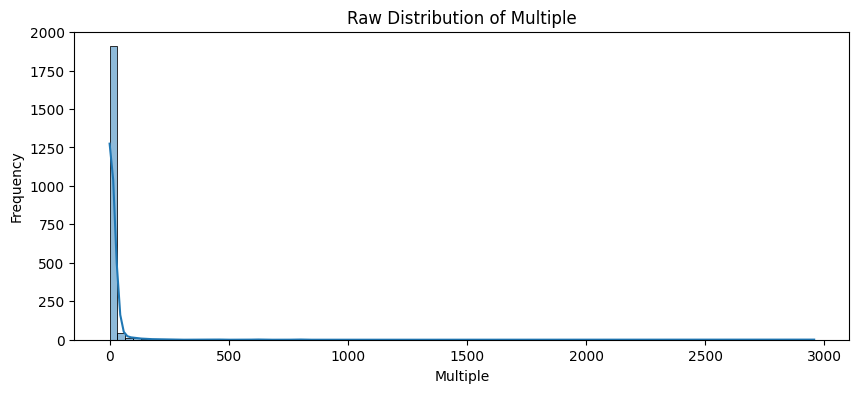

Log1p Range: 0.0 - 7.99243629347141


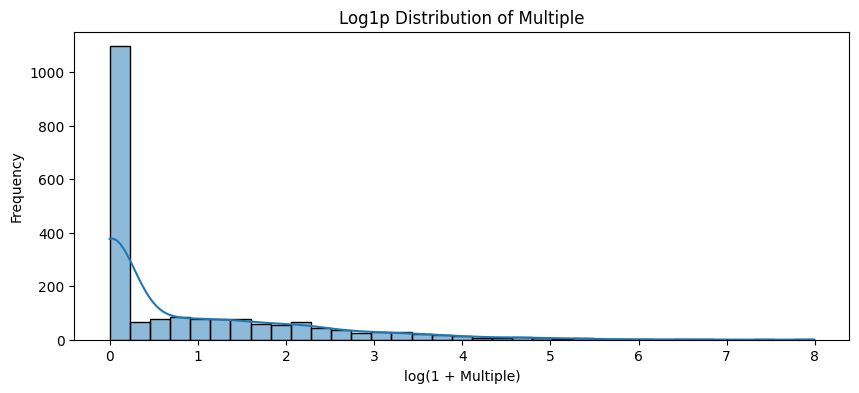

Bin Range: 0.0 - 8.0
multiple
(0.0, 0.5]    173
(0.5, 1.0]    175
(1.0, 1.5]    168
(1.5, 2.0]    137
(2.0, 2.5]    124
(2.5, 3.0]     66
(3.0, 3.5]     61
(3.5, 4.0]     34
(4.0, 4.5]     22
(4.5, 5.0]     18
(5.0, 5.5]     10
(5.5, 6.0]      3
(6.0, 6.5]      4
(6.5, 7.0]      2
(7.0, 7.5]      1
(7.5, 8.0]      1
Name: multiple, dtype: int64


/tmp/ipykernel_3582779/2327407702.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_counts = log_multiple.groupby(pd.cut(log_multiple, bins)).count()


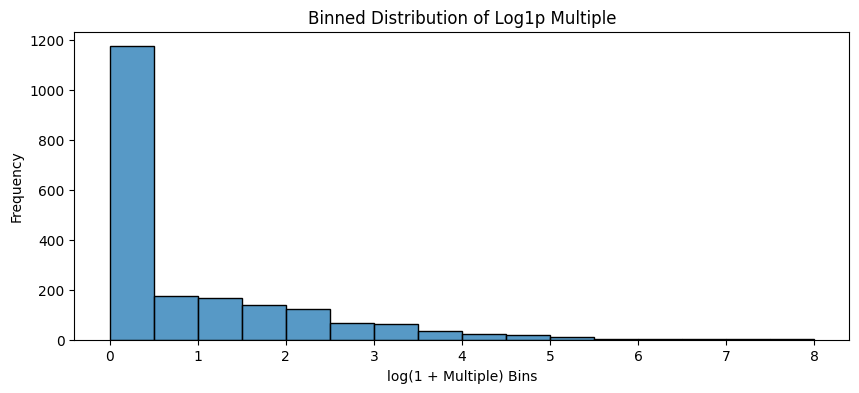

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Raw Range and Distribution
raw_min, raw_max = targets['multiple'].min(), targets['multiple'].max()
print(f"Raw Range: {raw_min} - {raw_max}")
plt.figure(figsize=(10, 4))
sns.histplot(targets['multiple'], kde=True)
plt.title('Raw Distribution of Multiple')
plt.xlabel('Multiple')
plt.ylabel('Frequency')
plt.show()

# 2. Log1p Range and Distribution
# np.log1p calculates log(1 + x), which is useful for handling zero values and reducing skewness.
log_multiple = np.log1p(targets['multiple'])
log_min, log_max = log_multiple.min(), log_multiple.max()
print(f"Log1p Range: {log_min} - {log_max}")
plt.figure(figsize=(10, 4))
sns.histplot(log_multiple, kde=True)
plt.title('Log1p Distribution of Multiple')
plt.xlabel('log(1 + Multiple)')
plt.ylabel('Frequency')
plt.show()

# 3. Bin Range and Distribution
bins = np.arange(np.floor(log_min), np.ceil(log_max) + 0.5, 0.5)
print(f"Bin Range: {bins.min()} - {bins.max()}")
binned_counts = log_multiple.groupby(pd.cut(log_multiple, bins)).count()
print(binned_counts)
plt.figure(figsize=(10, 4))
sns.histplot(log_multiple, bins=bins, kde=False)
plt.title('Binned Distribution of Log1p Multiple')
plt.xlabel('log(1 + Multiple) Bins')
plt.ylabel('Frequency')
plt.xticks(bins[::2]) # Adjust x-ticks for better readability if many bins
plt.show()
